In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

I0000 00:00:1788183394.669880   87572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788183396.112730   87572 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788183399.608410   87572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_train, y_train),(x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
print(x_train.shape)
print(x_train[1].shape)
print(x_test.shape)
print(x_test[1].shape)
print(y_train.shape)
print(y_test.shape)


(60000, 28, 28)
(28, 28)
(10000, 28, 28)
(28, 28)
(60000,)
(10000,)


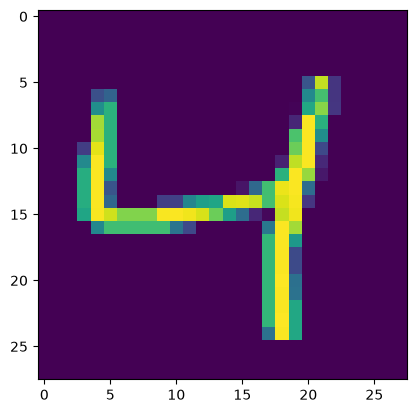

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_train[2])

In [5]:
x_train = x_train/255
x_test = x_test/255

In [6]:
model = Sequential()

model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation = 'softmax'))


E0000 00:00:1788183403.364918   87572 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer ='Adam', metrics=['accuracy']) #If use categorial_rossentropy, we have to onehot encode our classes


In [9]:
history = model.fit(x_train,y_train, epochs=10, validation_split=0.2)

Epoch 1/10


W0000 00:00:1788183403.839612   87572 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9172 - loss: 0.2892

W0000 00:00:1788183409.218409   87572 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9175 - loss: 0.2880 - val_accuracy: 0.9570 - val_loss: 0.1548
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9624 - loss: 0.1306 - val_accuracy: 0.9638 - val_loss: 0.1194
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9733 - loss: 0.0878 - val_accuracy: 0.9672 - val_loss: 0.1085
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9802 - loss: 0.0667 - val_accuracy: 0.9728 - val_loss: 0.0956
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9842 - loss: 0.0517 - val_accuracy: 0.9720 - val_loss: 0.0951
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9716 - val_loss: 0.0952
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9906 - loss: 0.0314 - val_accuracy: 0.9771 - val_loss: 0.0837
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9921 - loss: 0.0260 - val_accurac

In [10]:
y_prob = model.predict(x_test)

 66/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

W0000 00:00:1788183446.776801   87572 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


115/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [11]:
y_pred = y_prob.argmax(axis=1)

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.977

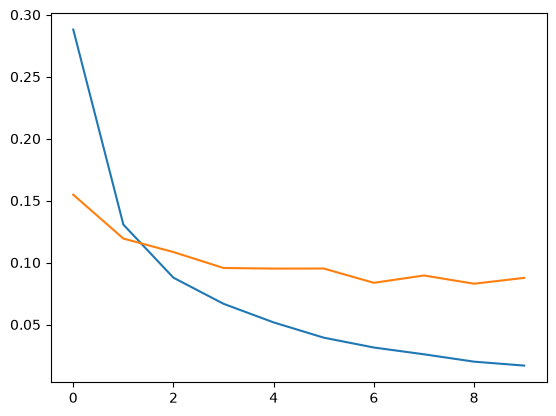

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

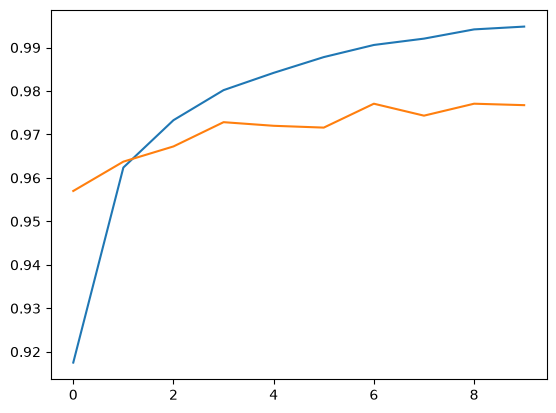

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

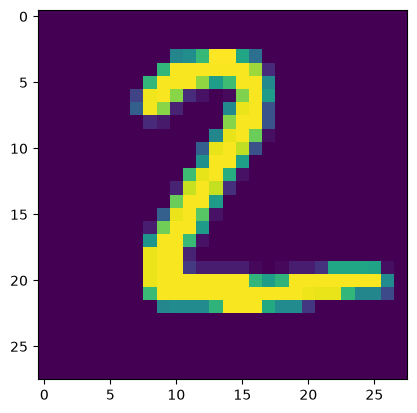

In [17]:
plt.imshow(x_test[1])

In [19]:
model.predict(x_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([2])